# The coverage matrix, measured through the C ABIs

`rational`'s M6 notebook (`PLAN.md` section 6). It rebuilds every one of the 182 rows of the
coverage matrix (PLAN.md section 3; the rows as `tests/coverage/matrix_rows.h` states them)
from the **shipping** libraries through their C ABIs: a within-family row is the named chain
`tap_sr_rational_create` constructs from its enumerator, a cross-family row is composed here
from `tap_sr_rational_create_stage` stages at the row's design divisors and `bridge`'s
converter through *its* C ABI (a notebook, like a test, may name a sibling: 4.2). Nothing is
re-implemented in Python; the analysis (bins, a DFT) is the only numpy.

It then checks the numbers the matrix test pins — MACs per output and latency, exact
rationals, at all four profiles — and measures every row's promise (2.1) with a tone battery at
`economy` and `transparent`: every image and alias candidate that lands at or below f_pass is at
or below −A, the passband flat within the stages' ripple candidates.

In [1]:
import pathlib, re, sys
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parents[1] / "bridge" / "notebooks"))
import figure_digest
figure_digest.install()
import tap_sr_rational_py as rp
import tap_sr_bridge_py as bp

print("rational", rp.version(), "bridge", bp.version())
assert rp.version() == bp.version() == (0, 5, 0)  # one family version (D13)

rational (0, 5, 0) bridge (0, 5, 0)


## The rows

The generated table: per row the source and destination rates, the ⚑ flag, the stages in order
with each rational stage's design divisor (`0/1` marks the bridge stage), and the pinned MACs
per output and latency in output frames per profile (super_economy, economy, balanced,
transparent).

In [2]:
text = (HERE.parent / "tests" / "coverage" / "matrix_rows.h").read_text()
ROWS = []
for m in re.finditer(r"ROW\((\d+), (\d+), (true|false), \(([^)]*)\), \(((?:d\(\d+, \d+\)(?:, )?)*)\), ([\d, ]+)\)", text):
    nums = [int(v) for v in m.group(6).split(",")]
    ROWS.append(dict(
        src=int(m.group(1)), dst=int(m.group(2)), flagged=m.group(3) == "true",
        stages=[s.strip() for s in m.group(4).split(",")],
        divisors=[Fraction(int(a), int(b)) if int(a) else None
                  for a, b in re.findall(r"d\((\d+), (\d+)\)", m.group(5))],
        macs=[Fraction(nums[4 * i], nums[4 * i + 1]) for i in range(4)],
        latency=[Fraction(nums[4 * i + 2], nums[4 * i + 3]) for i in range(4)],
    ))
PROFILES = ["super_economy", "economy", "balanced", "transparent"]
ATTEN = {"super_economy": 70.0, "economy": 70.0, "balanced": 70.0, "transparent": 120.0}
PASS_FRAC = {"super_economy": Fraction(1, 3), "economy": Fraction(3, 8),
             "balanced": Fraction(19, 48), "transparent": Fraction(5, 12)}
print(len(ROWS), "rows;", sum(r["flagged"] for r in ROWS), "flagged;",
      sum(not any(s.startswith("bridge") for s in r["stages"]) for r in ROWS), "within a family")

182 rows; 38 flagged; 92 within a family


## Building a row

A stage name is its ratio (`up_2` is 2/1, `ratio_3_4` is 3/4); `bridge_down<k>` and
`bridge_up<k>` are bridge's converter, whose machine is identical at every rate scale k
(bridge's 2.2), so k only says which rates its frames carry. Each part of a row is a converter
with its ratio; the row runs them in sequence, which `test_chain.cpp` shows is bit-identical to
`tap::dsp::chain`.

In [3]:
BRIDGE_LM = {"down": (147, 160), "up": (160, 147)}

def stage_ratio(name):
    if name.startswith("bridge"):
        return Fraction(*BRIDGE_LM["down" if "down" in name else "up"])
    if name.startswith("up_"):
        return Fraction(int(name[3:]), 1)
    if name.startswith("down_"):
        return Fraction(1, int(name[5:]))
    _, l, m = name.split("_")
    return Fraction(int(l), int(m))

class Part:
    """One converter of a row: a rational chain or stage, or bridge."""
    def __init__(self, conv, ratio, macs, latency):
        self.conv, self.ratio, self.macs, self.latency = conv, ratio, macs, latency

def bridge_part(name, profile):
    d = "down" if "down" in name else "up"
    c = bp.RatioConverter(direction=d, profile=profile)
    l, m = BRIDGE_LM[d]
    # bridge's cost per output is its taps per phase T; its group delay is
    # (L T - 1) / 2 at the composite rate, (L T - 1) / (2 M) output frames.
    return Part(c, Fraction(l, m), Fraction(c.taps), Fraction(l * c.taps - 1, 2 * m))

def build(row, profile):
    """The row's parts: one named chain within a family, else stages and bridge."""
    if not any(s.startswith("bridge") for s in row["stages"]):
        c = rp.Chain("_".join(row["stages"]), profile=profile)
        return [Part(c, c.ratio, c.macs_per_output, c.latency_output_frames)]
    parts = []
    for name, d in zip(row["stages"], row["divisors"]):
        if name.startswith("bridge"):
            parts.append(bridge_part(name, profile))
        else:
            r = stage_ratio(name)
            s = rp.Stage(r.numerator, r.denominator, profile=profile, divisor=(d.numerator, d.denominator))
            parts.append(Part(s, s.ratio, s.macs_per_output, s.latency_output_frames))
    return parts

def numbers(row, parts):
    """MACs per output and latency in output frames, exact, at the row's output rate."""
    rate, macs, lat = Fraction(row["src"]), Fraction(0), Fraction(0)
    for p in parts:
        rate *= p.ratio
        scale = rate / row["dst"]          # this part's output frames per chain output frame
        macs += p.macs * scale
        lat += p.latency / scale
    assert rate == row["dst"]
    return macs, lat

def run(parts, x):
    for p in parts:
        x = p.conv.process(x)
    return x

def frames_needed(parts, k):
    for p in reversed(parts):
        k = p.conv.frames_needed(k)
    return k

## The pinned numbers, reproduced

For every row at every profile: the MACs per output and the latency the shipping converters
report, composed at the row's output rate, against the pins `test_matrix.cpp` holds.

In [4]:
mismatches, checked = [], 0
TABLE = {}
for row in ROWS:
    for i, prof in enumerate(PROFILES):
        macs, lat = numbers(row, build(row, prof))
        checked += 1
        TABLE[(row["src"], row["dst"], prof)] = (macs, lat)
        if macs != row["macs"][i] or lat != row["latency"][i]:
            mismatches.append((row["src"], row["dst"], prof, macs, row["macs"][i], lat, row["latency"][i]))
print(f"{checked} (row, profile) pairs; {checked - len(mismatches)} reproduce both pins exactly")
for m in mismatches[:10]:
    print("MISMATCH", m)
assert not mismatches

728 (row, profile) pairs; 728 reproduce both pins exactly


## The promise, measured

A tone at input frequency f, an exact bin of an analysis window n output frames long whose
length makes every rate of the chain a bin too, so the rectangular-window DFT measures every
image and alias candidate (|k R_j ± f| folded, over every rate R_j along the chain) without
leakage beside the tone. Seven passband tones and up to five stopband tones per row; a candidate
counts when it lands at or below f_pass, the promise's band (2.1). The battery is the C++
matrix test's, run here on the float golden model through the C ABIs.

In [5]:
from math import gcd, lcm

def analysis_length(rates, target=8192):
    f_out, n0 = rates[-1], 1
    for r in rates:
        n0 = lcm(n0, f_out // gcd(r, f_out))
    return n0 * -(-target // n0)

def measure_row(row, prof):
    parts = build(row, prof)
    rates = [row["src"]]
    for p in parts:
        rates.append(int(rates[-1] * p.ratio))
    f_in, f_out = row["src"], row["dst"]
    r_min = min(f_in, f_out)
    f_pass = float(PASS_FRAC[prof]) * r_min
    f_stop = r_min - f_pass
    n = analysis_length(rates)
    _, lat = numbers(row, parts)
    skip = int(2 * float(lat)) + 64
    bin_hz = f_out / n
    pass_bin = int(f_pass / bin_hz)
    n_in = frames_needed(parts, skip + n)

    def tone(b):
        for p in parts:
            p.conv.reset()
        w = 2 * np.pi * b * f_out / n / f_in
        y = run(parts, (0.5 * np.sin(w * np.arange(n_in))).astype(np.float32)).astype(np.float64)
        spec = np.abs(np.fft.rfft(y[skip:skip + n])) * 2 / n
        fold = lambda k: (k % n) if (k % n) <= n // 2 else n - (k % n)
        own, cands = fold(b), set()
        for r in rates:
            ru = r * n // f_out
            k = 0
            while k * ru <= 2 * n + b:
                cands.add(fold(k * ru + b)); cands.add(fold(abs(k * ru - b))); k += 1
        spur = max([spec[c] for c in cands if c != own and 0 < c <= pass_bin] or [1e-30])
        return 20 * np.log10(spur / 0.5), 20 * np.log10(spec[own] / 0.5), own

    worst_spur, worst_dev = -400.0, 0.0
    for frac in (0.1, 0.3, 0.5, 0.7, 0.85, 0.95, 0.99):
        b = int(frac * f_pass / bin_hz)
        if b >= 1:
            s, g, _ = tone(b)
            worst_spur, worst_dev = max(worst_spur, s), max(worst_dev, abs(g))
    nyq_in = f_in / 2
    if f_stop < nyq_in:
        for f in sorted({f_stop * 1.001, f_stop * 1.05, f_stop + 0.25 * (nyq_in - f_stop),
                         f_stop + 0.5 * (nyq_in - f_stop), nyq_in * 0.98}):
            if f_stop < f < nyq_in:
                s, g, own = tone(int(np.ceil(f / bin_hz)))
                worst_spur = max(worst_spur, s)
                if own <= pass_bin:
                    worst_spur = max(worst_spur, g)
    n_stages = sum(1 for s in row["stages"])
    delta = n_stages * (0.0001 if ATTEN[prof] >= 100 else 0.01)
    return worst_spur, worst_dev, delta

RESULTS = {}
for prof in ("economy", "transparent"):
    for row in ROWS:
        RESULTS[(row["src"], row["dst"], prof)] = measure_row(row, prof)
    spurs = [RESULTS[(r["src"], r["dst"], prof)][0] for r in ROWS]
    devs = [RESULTS[(r["src"], r["dst"], prof)][1] for r in ROWS]
    ok = sum(RESULTS[(r["src"], r["dst"], prof)][0] <= -ATTEN[prof]
             and RESULTS[(r["src"], r["dst"], prof)][1] <= RESULTS[(r["src"], r["dst"], prof)][2] for r in ROWS)
    print(f"{prof:12s}: {ok}/182 rows meet the promise; worst candidate {max(spurs):.2f} dB "
          f"(spec -{ATTEN[prof]:.0f}), worst passband deviation {max(devs):.5f} dB")

economy     : 182/182 rows meet the promise; worst candidate -71.34 dB (spec -70), worst passband deviation 0.00805 dB


transparent : 182/182 rows meet the promise; worst candidate -121.57 dB (spec -120), worst passband deviation 0.00002 dB


## The cost and the delay of every row

MACs per output against latency at `economy`, one mark per ordered pair: within a family, across
families, and the ⚑ rows (bridge running at twice the output rate or more: covered, not
recommended). Both axes logarithmic; the table below the figure is the same data by class.

[ figure ] digest 6b26187d1a2e8649 (3 arrays)


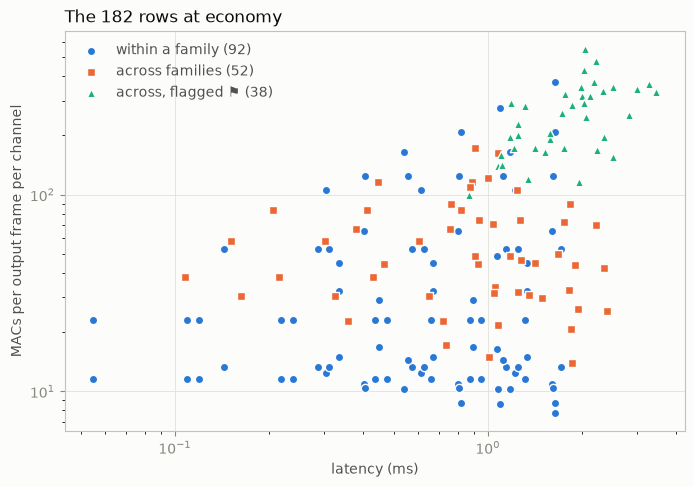

class                rows MAC/out min   median      max  latency ms max
within a family        92         7.8     23.0    373.0            1.72
across families        52        13.9     46.8    172.3            2.40
across, flagged ⚑      38        99.0    253.7    550.6            3.46


In [6]:
CLASSES = [("within a family", "#2a78d6", "o"),
           ("across families", "#eb6834", "s"),
           ("across, flagged ⚑", "#1baf7a", "^")]

def klass(row):
    if not any(s.startswith("bridge") for s in row["stages"]):
        return 0
    return 2 if row["flagged"] else 1

fig, ax = plt.subplots(figsize=(8, 5.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for k, (label, color, marker) in enumerate(CLASSES):
    pts = [(1e3 * float(TABLE[(r["src"], r["dst"], "economy")][1]) / r["dst"],
            float(TABLE[(r["src"], r["dst"], "economy")][0])) for r in ROWS if klass(r) == k]
    xs, ys = zip(*pts)
    ax.scatter(xs, ys, s=36, color=color, marker=marker, label=f"{label} ({len(pts)})",
               edgecolors="#fcfcfb", linewidths=1.0, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("latency (ms)", color="#52514e")
ax.set_ylabel("MACs per output frame per channel", color="#52514e")
ax.set_title("The 182 rows at economy", color="#0b0b0b", loc="left")
ax.grid(True, which="major", color="#e1e0d9", linewidth=0.6, zorder=0)
for s in ax.spines.values():
    s.set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.legend(frameon=False, labelcolor="#52514e", loc="upper left")
plt.show()

print(f"{'class':20s} {'rows':>4s} {'MAC/out min':>11s} {'median':>8s} {'max':>8s} {'latency ms max':>15s}")
for k, (label, _, _) in enumerate(CLASSES):
    rs = [r for r in ROWS if klass(r) == k]
    m = sorted(float(TABLE[(r["src"], r["dst"], "economy")][0]) for r in rs)
    l = max(1e3 * float(TABLE[(r["src"], r["dst"], "economy")][1]) / r["dst"] for r in rs)
    print(f"{label:20s} {len(rs):4d} {m[0]:11.1f} {m[len(m) // 2]:8.1f} {m[-1]:8.1f} {l:15.2f}")

## Summary

Every row is rebuilt from the shipping libraries; the pinned numbers are reproduced exactly and
the tone battery's verdicts match the C++ matrix test's (`test_matrix.cpp`, which runs the same
battery in double). The C ABI's surface, as built, is recorded in `PLAN.md` section 6 (M6) with
`nm -D`.